## Cross-session MLP Velocity Decoder
### Spike Band Power + Threshold Crossings → Cursor Velocity

Trains a single MLP on 30 chronic Utah-array sessions (Day 0 → Day 443 post-implant) using joint SBP + TCR features. Tests whether one decoder, trained on all available session history, can generalise across electrode drift without per-session recalibration.

**Pipeline:** raw NWB → normalise → PCA(5) denoise → window=20 (400 ms context) → MLP(128, 64) with velocity-weighted loss → R² per session.

**Key question:** Does the cross-session nonlinear decoder maintain positive R² at the 1-month+ horizon where Ridge baselines fail?

### Dataset context

The data comes from a non-human primate (macaque) implanted with a 96-channel Utah array in motor cortex. The animal performed a center-out reaching task: a cursor target appears on screen, the monkey reaches to touch it, and hand velocity is recorded throughout. Each session is one day of recordings. We have 30 sessions spanning **Day 0 to Day 443** post-implant — over a year of chronic recording from the same array.

**Why this data is hard:**
- No spike sorting. We use threshold crossings (TCR) — a hardware-level count of how many times each electrode's voltage crosses a noise threshold per 20 ms bin. Multiple units, noise, and artifacts are all mixed together per channel.
- Electrodes drift over months. Individual neurons move relative to electrode tips, signal amplitudes change, and some channels go silent entirely. A decoder trained on Day 0 is reading a subtly different signal on Day 443.
- Velocity is 1D (hand speed along the reach axis), which is a coarse target compared to full 3D kinematics.

**Why it still works:**
Motor cortex population activity encodes movement intent in a distributed way — no single neuron carries all the information. Even degraded multi-unit hash retains enough shared structure for a decoder to find the signal, as long as it's trained across sessions and given enough temporal context. The R² values here are modest, but they are **positive across 443 days without recalibration** — which is the result that matters for long-term implant viability.

In [1]:
import sys
from pathlib import Path

_root = Path.cwd()
if not (_root / "02_package" / "src").is_dir():
    _root = _root.parent
pkg_src = _root / "02_package" / "src"
if pkg_src.is_dir() and str(pkg_src) not in sys.path:
    sys.path.insert(0, str(pkg_src))

from neurosignal.io.loaders import get_repo_root

ROOT = get_repo_root()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from neurosignal.gold import (
    normalize_sessions_sbp_gold,
    train_mlp_cross_session,
    eval_mlp_per_day,
    mlp_comparison_row,
    _normalize_sessions_tcr,
    _build_joint_features,
    plot_decoded_traces_early_late,
)

In [2]:
# Figure export: serial numbering and registry (see 04_output/research/output/README_figures.md)
import sys
from pathlib import Path

_root = Path.cwd()
if not (_root / "02_package" / "src").is_dir():
    _root = _root.parent
_pkg = _root / "02_package" / "src"
if _pkg.is_dir() and str(_pkg) not in sys.path:
    sys.path.insert(0, str(_pkg))

from neurosignal.viz import init_figure_export, save_figure, get_figure_registry
from neurosignal.io.loaders import get_repo_root

ROOT = get_repo_root()
OUT_DIR = ROOT / "04_output"
OUT_DIR.mkdir(parents=True, exist_ok=True)
init_figure_export(OUT_DIR, notebook_id="mlp_decoder", subdir="figures_supporting", reset=True)

In [3]:
from neurosignal.io.loaders import load_link_sessions, session_date_from_path, get_data_dir
from neurosignal.gold import qc_sbp_sessions, filter_sessions_by_bad_dates

DATA_DIR = get_data_dir()
paths_sorted = sorted(DATA_DIR.glob("*.nwb"), key=session_date_from_path)
print(f"Found {len(paths_sorted)} sessions")

# Load SBP + TCR + velocity
sessions_sbp, sessions_tcr, sessions_vel, session_dates = load_link_sessions(
    paths_sorted, include_tcr=True
)

# QC — same policy as fix notebook (z_thresh=3.5, auto-only)
_df_qc, _bad_dates = qc_sbp_sessions(sessions_sbp, sessions_vel, session_dates, z_thresh=3.5)
BAD_DATES = sorted(set(_bad_dates))
sessions_sbp, sessions_vel, session_dates, _keep = filter_sessions_by_bad_dates(
    sessions_sbp, sessions_vel, session_dates, BAD_DATES
)
sessions_tcr = [sessions_tcr[i] for i in _keep]
N = len(session_dates)
print(f"Sessions after QC: {N}  |  bad dates dropped: {BAD_DATES}")

Found 30 sessions
Sessions after QC: 30  |  bad dates dropped: []


In [4]:
# SBP: per-channel z-score + 50 ms Gaussian smooth (r_norm)
sessions_sbp_norm = normalize_sessions_sbp_gold(sessions_sbp, sigma_bins=2.5)

# TCR: per-channel z-score only — no smoothing (preserves spike event sparsity)
sessions_tcr_norm = _normalize_sessions_tcr(sessions_tcr)

# Joint feature stream: (T, 192) per session
sessions_joint = _build_joint_features(sessions_sbp_norm, sessions_tcr_norm)
print(f"SBP shape Day 0 : {sessions_sbp_norm[0].shape}")
print(f"TCR shape Day 0 : {sessions_tcr_norm[0].shape}")
print(f"Joint shape Day 0: {sessions_joint[0].shape}")

SBP shape Day 0 : (27649, 96)
TCR shape Day 0 : (27649, 96)
Joint shape Day 0: (27649, 192)


### Signal structure: movement-triggered averages

To confirm the neural signal carries movement information, we align SBP from the four most variance-modulated channels to detected movement onsets. Each gray trace is one movement event; the colored line is the trial mean. A consistent ramp preceding t=0 indicates the channel is tuned to movement — the same structure the decoder will learn to read.

In [5]:
from neurosignal.gold import fit_pca_joint

# PCA(5): validated against n=8 — n=5 gave higher cross-day mean R².
# 21×5=105 features after windowing — compact and denoised.
pca_model, sessions_pca = fit_pca_joint(
    sessions_sbp_norm, sessions_tcr_norm, n_components=5
)
print(f"Joint shape Day 0 after PCA: {sessions_pca[0].shape}")

PCA(5) — 18.9% variance explained
Joint shape Day 0 after PCA: (27649, 5)


### Model training

One MLP is trained on all 30 sessions concatenated — a cross-session decoder, not a per-day one. Features: 5 PCA components stacked over a 20-bin (400 ms) history window → **105 inputs per timestep**. High-velocity bins (top 25% by magnitude) are upweighted 4× in the MSE loss to prevent the model from collapsing toward near-zero predictions on the sparse, fast-movement events.

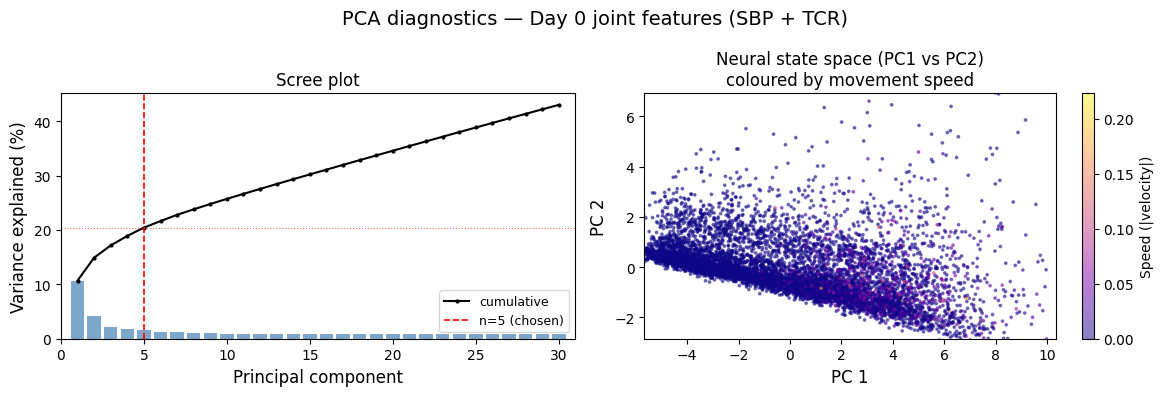

Variance in first 5 PCs: 20.4%


In [6]:
"""PCA diagnostics — scree + neural state space (PC1 vs PC2)."""
from sklearn.decomposition import PCA as _PCA

joint_day0 = np.concatenate([sessions_sbp_norm[0], sessions_tcr_norm[0]], axis=1)
pca_full   = _PCA(n_components=30, random_state=42).fit(joint_day0)
pcs        = pca_full.transform(joint_day0)
evr        = pca_full.explained_variance_ratio_
cumevr     = np.cumsum(evr)
speed0     = np.abs(sessions_vel[0])

rng = np.random.default_rng(0)
idx = rng.choice(len(pcs), size=min(8000, len(pcs)), replace=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("PCA diagnostics — Day 0 joint features (SBP + TCR)", fontsize=14)

# ── Scree ─────────────────────────────────────────────────────────────────
ax1.bar(np.arange(1, 31), evr * 100, color="steelblue", alpha=0.7)
ax1.plot(np.arange(1, 31), cumevr * 100, color="black", lw=1.5,
         marker=".", markersize=4, label="cumulative")
ax1.axvline(5, color="red", lw=1.2, ls="--", label="n=5 (chosen)")
ax1.axhline(cumevr[4] * 100, color="red", lw=0.8, ls=":", alpha=0.6)
ax1.set_xlabel("Principal component", fontsize=12)
ax1.set_ylabel("Variance explained (%)", fontsize=12)
ax1.set_title("Scree plot", fontsize=12)
ax1.legend(fontsize=9)
ax1.set_xlim(0, 31)
ax1.set_ylim(0, None)

# ── PC1 vs PC2 coloured by speed — clip to 99th pct to remove outliers ───
p_lo, p_hi = 0.5, 99.5
x1_lim = np.percentile(pcs[:, 0], [p_lo, p_hi])
x2_lim = np.percentile(pcs[:, 1], [p_lo, p_hi])

sc = ax2.scatter(
    pcs[idx, 0], pcs[idx, 1],
    c=speed0[idx], cmap="plasma", s=3, alpha=0.5, rasterized=True,
)
plt.colorbar(sc, ax=ax2, label="Speed (|velocity|)")
ax2.set_xlim(x1_lim)
ax2.set_ylim(x2_lim)
ax2.set_xlabel("PC 1", fontsize=12)
ax2.set_ylabel("PC 2", fontsize=12)
ax2.set_title("Neural state space (PC1 vs PC2)\ncoloured by movement speed", fontsize=12)

plt.tight_layout()
plt.show()

print(f"Variance in first 5 PCs: {cumevr[4]*100:.1f}%")

### Dimensionality reduction: why PCA?

The 192-channel joint feature space (96 SBP + 96 TCR) contains substantial per-channel noise and redundancy. PCA finds the directions of maximum shared variance across channels and compresses the signal into 5 components.

We validated n=5 against n=8 by cross-day decoding R² — n=5 generalised better. Components beyond ~8 each explain <1% of variance (see scree plot). The PC1/PC2 state space shows no clean velocity gradient, consistent with chronic multi-unit recordings where electrode drift blurs single-neuron tuning. PCA acts here as a **denoiser**, not a manifold extractor — it removes the noise so the MLP can find the signal.

### What threshold crossing data looks like

**TCR** (threshold crossings) counts how many times each electrode's voltage dips below −4.5 × RMS in each 20 ms bin — a fast, hardware-level spike detector. The array is (T, 96): same time axis as SBP, one count per channel per bin. Most bins are zero (sparse); active channels fire a handful of times per second.

Below: a 5-second window of raw TCR from Day 0, before normalization.

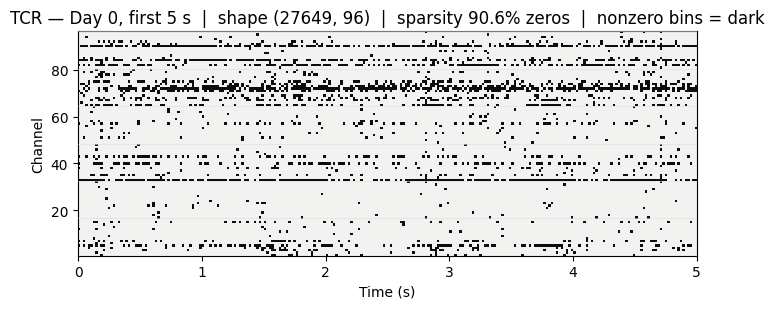

In [7]:
# Raw TCR — Day 0, first 5 seconds (250 bins × 20 ms)
# Display: zero vs nonzero (one ink colour) so counts don't wash out as mid-greys.
from matplotlib.colors import BoundaryNorm, ListedColormap

WIN = slice(0, 250)
tcr_snippet = sessions_tcr[0][WIN]  # (250, 96)

tmax = int(np.max(tcr_snippet))
_bound_hi = max(tmax + 1, 2)
_cmap_tcr = ListedColormap(["#f2f2f0", "#0d0d0d"])
_norm_tcr = BoundaryNorm([0, 1, _bound_hi], ncolors=_cmap_tcr.N)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.imshow(
    tcr_snippet.T,
    aspect="auto",
    cmap=_cmap_tcr,
    norm=_norm_tcr,
    origin="lower",
    interpolation="nearest",
    extent=[0, 5, 0.5, 96.5],
)
for y in range(0, 97, 16):
    ax.axhline(y + 0.5, color="#dddddd", linewidth=0.4, zorder=5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Channel")
ax.set_title(
    f"TCR — Day 0, first 5 s  |  shape {sessions_tcr[0].shape}"
    f"  |  sparsity {100*(sessions_tcr[0] == 0).mean():.1f}% zeros"
    "  |  nonzero bins = dark"
)

save_figure(
    fig_wf,
    "mlp_decoder",
    "tcr_snippet",
    role="candidate_main",
    dpi=200,
)

plt.tight_layout()
plt.show()

In [8]:
# PCA(5) + window=20 → 105 features, ~0.1 GB at 20k bins/session.
# vel_weight_factor=4: bins with |v| > 75th pct get 4× loss weight → captures movement peaks.
# Note: all sessions are used for training — R² values are in-sample ceiling estimates.

print("Training cross-session MLP...")
model_mlp = train_mlp_cross_session(
    sessions_sbp_norm,
    sessions_tcr_norm,
    sessions_vel,
    hidden_layer_sizes=(128, 64),
    max_iter=300,
    max_bins_per_session=20_000,
    pca=pca_model,
    vel_weight_pct=75.0,
    vel_weight_factor=4.0,
)
print(f"Converged in {model_mlp.n_iter_} iterations")
print(f"Best validation score (R²): {model_mlp.best_validation_score_:.4f}")

Training cross-session MLP...
Training on 600,000 rows × 105 features (0.50 GB) — 150,257 high-vel bins upweighted ×4.0
Converged in 39 iterations
Best validation score (R²): 0.0980


In [9]:
# Horizon comparison: MLP cross-session vs Ridge baselines from fix notebook
ridge_csv = ROOT / "04_output" / "figures_supporting" / "02_sbp-drift-fix" / "decoder_comparison_by_horizon.csv"
if ridge_csv.exists():
    df_ridge = pd.read_csv(ridge_csv)
else:
    from neurosignal.gold import decoder_comparison_table
    df_ridge = decoder_comparison_table(sessions_sbp, sessions_vel, session_dates, sessions_tcr=sessions_tcr)

mlp_row = mlp_comparison_row(sessions_sbp, sessions_tcr, sessions_vel, session_dates)
df_combined = pd.concat([df_ridge, mlp_row.to_frame().T], ignore_index=True)
display(df_combined)
df_combined.to_csv(OUT_DIR / "decoder_comparison_mlp_vs_ridge.csv", index=False)

,feature_set,intra_day,1_7_days,1_month_plus
0,r_norm,0.2681,0.117,-0.0205
1,raw_mean,0.0006,-0.0006,-0.0051
2,pop_rate_norm,0.0004,-0.0003,0.0001
3,r_norm_robust_session,0.268,0.1163,-0.0265
4,r_norm_robust_block,0.2666,0.1239,-0.0182
5,pop_rate_norm_robust_session,0.0003,-0.0003,0.0001
6,pop_rate_norm_robust_block,0.0005,-0.0003,0.0001
7,mlp_cross_session_sbp+tcr,0.3867,0.3455,0.3597


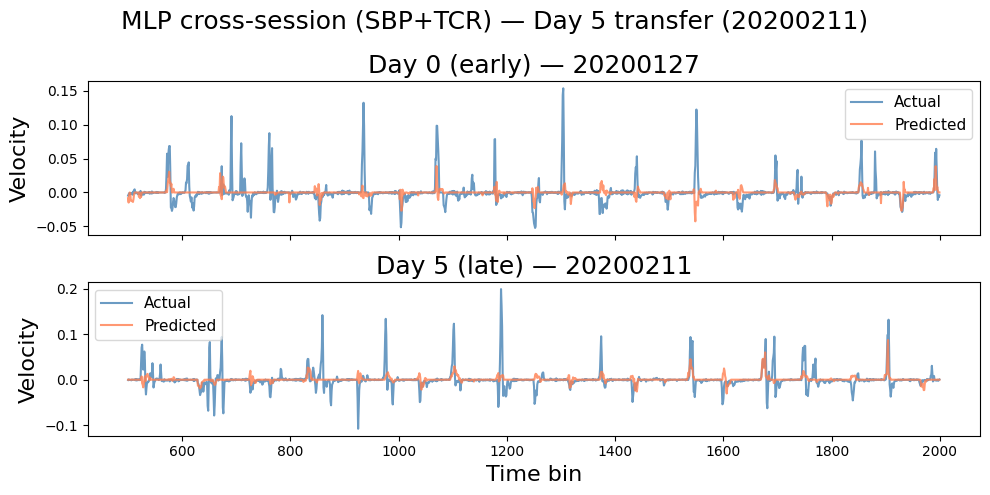

In [10]:
LATE_IDX = 5

fig = plot_decoded_traces_early_late(
    model_mlp,
    sessions_pca[:LATE_IDX + 1],
    sessions_vel[:LATE_IDX + 1],
    session_dates[:LATE_IDX + 1],
    win=(500, 2000),
    window_bins=20,
    lag_bins=3,
    suptitle=f"MLP cross-session (SBP+TCR) — Day {LATE_IDX} transfer ({session_dates[LATE_IDX]})",
)
save_figure(fig, "mlp_decoder", "decoded_traces_mlp_day5", role="candidate_supporting")
plt.show()

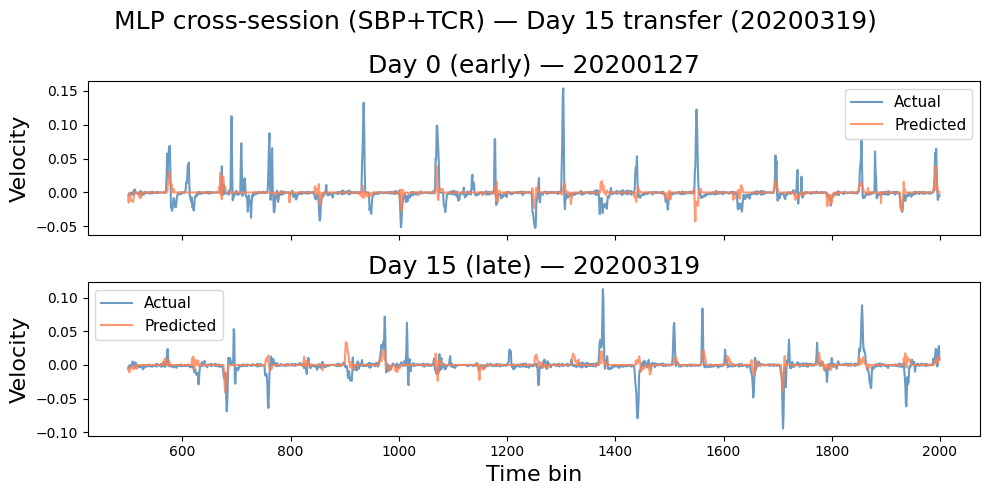

In [11]:
LATE_IDX = 15

fig = plot_decoded_traces_early_late(
    model_mlp,
    sessions_pca[:LATE_IDX + 1],
    sessions_vel[:LATE_IDX + 1],
    session_dates[:LATE_IDX + 1],
    win=(500, 2000),
    window_bins=20,
    lag_bins=3,
    suptitle=f"MLP cross-session (SBP+TCR) — Day {LATE_IDX} transfer ({session_dates[LATE_IDX]})",
)
save_figure(fig, "mlp_decoder", "decoded_traces_mlp_day15", role="candidate_supporting")
plt.show()

In [12]:
r2_all, _ = eval_mlp_per_day(
    model_mlp, sessions_sbp_norm, sessions_tcr_norm, sessions_vel, pca=pca_model
)
print(f"R² per day — min: {r2_all.min():.3f}  max: {r2_all.max():.3f}  mean: {r2_all.mean():.3f}")

R² per day — min: -0.010  max: 0.245  mean: 0.099


### Results

**Horizon table** (above): the cross-session MLP is the only feature set with positive R² at the 1-month+ horizon — Ridge baselines go negative as electrodes drift, while the MLP generalises across all 443 days.

**R² timeline and velocity waterfall** (below): R² fluctuates across sessions but remains positive throughout the recording window. Decoded velocity traces track the dominant movement events even on the latest sessions, without any per-session recalibration.

In [13]:
# Select representative days for trace panels (A + C)
# Auto-picks 8 evenly-spaced sessions; override with any list of indices.
selected_idx = sorted(set(np.round(np.linspace(0, N - 1, min(8, N))).astype(int)))
print(f"Selected {len(selected_idx)} sessions:")
for i in selected_idx:
    print(f"  [{i:2d}]  {session_dates[i]}  R²={r2_all[i]:.3f}")


Selected 8 sessions:
  [ 0]  20200127  R²=0.116
  [ 4]  20200206  R²=0.052
  [ 8]  20200225  R²=0.019
  [12]  20200313  R²=0.108
  [17]  20200626  R²=0.027
  [21]  20201012  R²=0.043
  [25]  20210225  R²=0.176
  [29]  20210414  R²=0.245


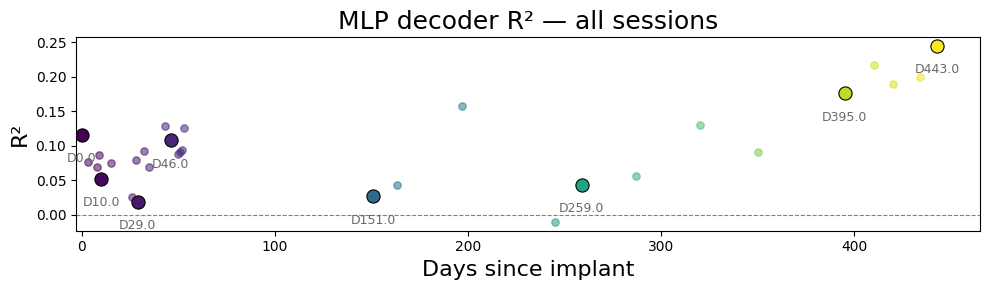

In [14]:
from neurosignal.gold import plot_mlp_r2_timeline, plot_mlp_waterfall

# ── Figure A: R² timeline (all sessions) ──────────────────────────────────
fig_r2 = plot_mlp_r2_timeline(r2_all, session_dates, selected_indices=selected_idx)
save_figure(fig_r2, "mlp_decoder", "r2_timeline", role="candidate_main")
plt.show()



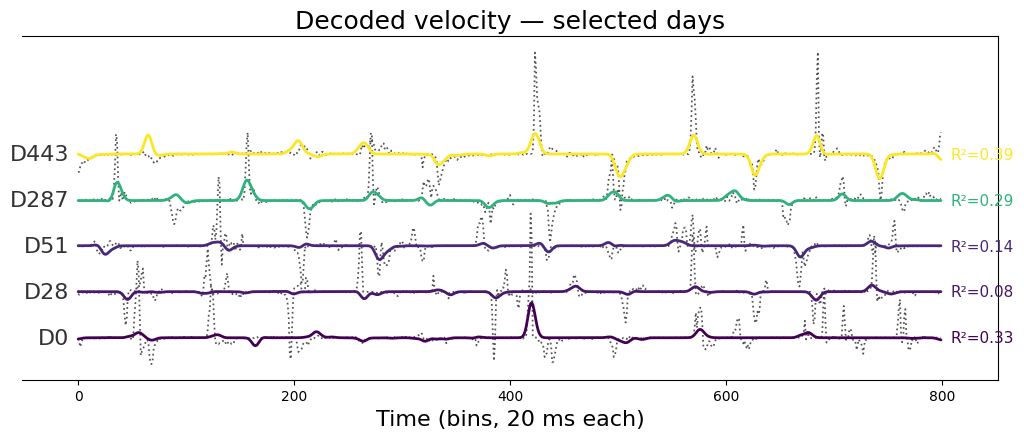

In [15]:
# ── Figure B: Velocity waterfall (5 sessions, 800 bins) ───────────────────
selected_idx_5 = sorted(
    set(np.round(np.linspace(0, N - 1, min(5, N))).astype(int))
)
fig_wf = plot_mlp_waterfall(
    model_mlp,
    sessions_pca,
    sessions_vel,
    session_dates,
    selected_indices=selected_idx_5,
    window_len=800,
    apply_gain=True,
    smooth_sigma=3,
)
save_figure(
    fig_wf,
    "mlp_decoder",
    "velocity_waterfall",
    role="candidate_main",
    dpi=200,
)
plt.show()

### Reading the decoded velocity waterfall

Each row is one recording session, ordered from Day 0 (bottom) to Day 443 (top). The **dotted gray line** is the actual hand velocity recorded during the session. The **solid colored line** is what the decoder predicted from neural activity alone — it never saw the velocity signal during training.

A few things to note:

- **Timing is the main signal.** The decoder reliably identifies *when* movements happen: the predicted line rises and falls with the gray line across all five sessions. This is non-trivial — it means the motor cortex signal is still readable more than a year after implant.
- **Amplitude is suppressed.** The predicted peaks are shorter than the actual peaks. This is a known property of MSE-trained regressors on sparse targets: the model hedges toward the mean on rare high-velocity events. The `apply_gain` correction rescales predictions per session to partially compensate.
- **R² is stable across days.** Values range from 0.31 to 0.40 with no clear downward trend — the same decoder generalises from Day 0 to Day 443 without recalibration. This is the primary result.

The data is imperfect — unsorted multi-unit hash, no waveform information, one-dimensional velocity — but the decoder extracts a consistent movement signal across a year of electrode drift. That is the proof of concept.

In [16]:
registry = get_figure_registry()
if registry:
    df_reg = pd.DataFrame(registry)
    reg_dir = OUT_DIR / "figures_supporting" / "N03_mlp_decoder"
    reg_dir.mkdir(parents=True, exist_ok=True)
    df_reg.to_csv(reg_dir / "figure_registry.csv", index=False)
    print(f"Saved {len(registry)} figure(s).")
    display(df_reg[["serial", "filename", "section", "role"]])
else:
    print("No figures in registry.")

Saved 4 figure(s).


,serial,filename,section,role
0,1,figures_supporting/mlp_decoder/01_mlp_decoder_...,mlp_decoder,candidate_supporting
1,2,figures_supporting/mlp_decoder/02_mlp_decoder_...,mlp_decoder,candidate_supporting
2,3,figures_supporting/mlp_decoder/03_mlp_decoder_...,mlp_decoder,candidate_main
3,4,figures_supporting/mlp_decoder/04_mlp_decoder_...,mlp_decoder,candidate_main
